# Condensator Ontwerpopdracht

Bij het vak elektromagnetisme zullen jullie in de eerste paar weken diep ingaan op de elektrostatica. Parallel hieraan zullen we bij het vak DEF-D, naast de fysieke ontwerpopdrachten en colleges, deze simulatie-ontwerpopdracht behandelen. Deze simulatie-opdracht is weer nauw verwoven met de tweede fysieke ontwerpopdracht die in week 3.3 gegeven wordt. Je moet het grootste deel van deze simulatie opdracht afronden voordat je aan de fysieke ontwerpopdracht van week 3.3 begint. Het laatste stuk van deze simulatie opdracht maak je na afloop van de fysieke opdracht. De deadline voor het inleveren van deze simulatie-opdracht is in week 3.4

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

In deze simulatie opdracht beginnen we met een aantal simulaties van verschillende situaties, die jullie daarna zullen interpreteren. Daarna zal wat essentiële voorbereiding op de tweede fysieke ontwerpopdracht besproken worden. En als laatste zal dieper ingegaan worden op hoe jullie metingen van de tweede ontwerpopdracht afwijken van de theorie.

De opdracht bestaat uit de volgende sub-opdrachten die je moet doen voordat je begint aan de fysieke ontwerpopdracht van week 3.3:
1) Een puntlading in de oorsprong.
2) Een uniform geladen schijf bestaande uit puntladingen.
3) Een geladen schijf op een constant potentiaal.
4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$.
5) Voorbereidende opdracht voor de DEF ontwerpopdracht.

Na de fysieke ontwerpopdracht van week 3.3 kan je ten slotte het laatste deel doen:

6) Reflectie opdracht voor na de fysieke ontwerpopdracht.

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.4 beoordeeld en herkansingen zijn in week 3.5, zie de studiehandleiding voor details.
   
Technische Instructies:
- Git clone (als nog niet gedaan) het DEF repo en maak een branch voor werken aan deze opdracht. Nodig je groepsgenoot uit als collaborator. Hiervoor staat een manual op brightspace.
- Dit notebook maakt gebruik van een aantal functies die in het bestand ```functions_electrostatics.py``` staan. Dit bestand moet in dezelfde map (folder) staan als dit notebook. Als je git clone doet, gaat dat automatisch goed, maar verplaats dit notebook dus niet naar een andere map, mail het niet naar een mede-student, etc. Als je niet weet wat een map (folder) en een bestand is, bekijk dan [deze tutorial](https://teachbooks.io/files-and-folders/EN/intro.html).

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Bij elke code cel staat aangegeven of jij hem moet aanpassen of alleen runnen. Lees bij cellen die je moet runnen, maar niet hoeft aan te passen, goed de code door om daarvan te leren en te gebruiken in de cellen die je wel moet aanpassen.

Elektrostatica Opmerkingen:
- In deze opdracht zullen jullie verschillende problemen bestuderen die as-symmetrie hebben. De opdrachten zullen daardoor, cilindrische coördinaten ($r$,$\phi$,$z$) gebruiken, waarbij $r$ de afstand tot de $z$ as is, $z$ de hoogte en $\phi$ de hoek met de $x$-as. Alle gebruikte problemen zullen ook in de $\phi$ richting symmetrisch zijn en die coördinaat zal dus niet uitmaken.
- Voor elke sub-opdracht zal eerst het potentiaal bepaald worden en daarna zal het elektrische veld bepaald worden met de "finite difference" methode. Dit is een methode om de afgeleide te nemen van een dataset. Deze methode is geen onderdeel van de leerdoelen van het vak en komt later in je studie aan bod. We gebruiken "finite difference" hier als gereedschap en als voorbeeld van wat je later nog tegen gaat komen.



Vul de informatie in deze cel in:

| Groep: 29     |  |
| :-------------|:-------------|
| Batu Sönmez| 6175163 |
| Christiaan Paardenkooper| 6453902 |

In [1]:
# Run deze cel, pas deze niet aan
import numpy as np
import matplotlib.pyplot as plt
from functions_electrostatics import *
#from IPython import display
from IPython.display import Image, display


epsilon0 = 8.854e-12  # permittiviteit van vacuum (F/m)

"""============================================================================================
We first define the size of the domain of calculation and spatial discretization of the domain
"""

# Grid van het rekendomein; het veld wordt berekend in het (r,z)-vlak (asymmetrie):
width_domain = 5  # (m)
height_domain = width_domain  # maximum afstand van de schijf tot de grond, boven en beneden (m)
grid_step = 0.1  # grid stap grootte (m)

### 1) Een puntlading in de oorsprong

In deze opdracht gaan we in op een numerieke benadering van het potentiaal en elektrische veld rond een puntlading in de oorsprong. 

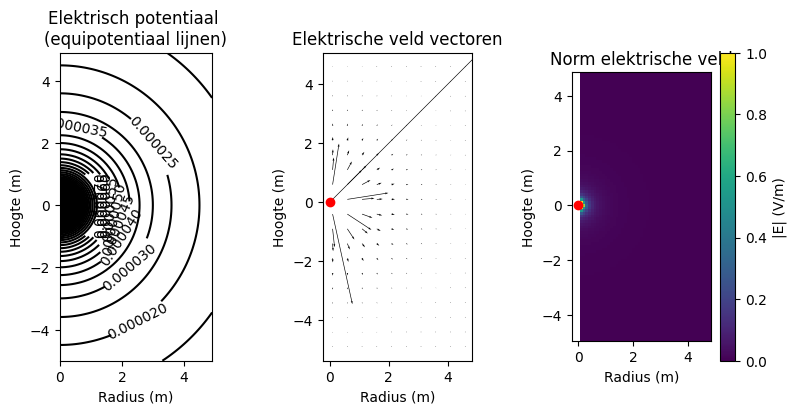

In [2]:
# Run deze cel, pas de cel niet aan
charge_one_point = 1e-14  # lading van 1 punt (C)

r, z, B = initialize_plane_grid_for_pt_charge_at_origin(height_domain, width_domain, grid_step)
V = calculate_V_point_charge_at_origin(charge_one_point, r, z)

Er, Ez, normE = compute_E_pt_charge(V, B, grid_step)  # gebruik de centered finite-difference method
# met Er de r-component, Ez de z-component en normE de norm van het elektrische veld

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_pt_charge_at_origin(Ez, Er, normE, V, r, z, grid_step)


##### Vraag 1a Het potentiaal rond een puntlading

1. Bepaal welke index correspondeert met $z = 0$ m.
2. Plot de log van het potentiaal tegen de log van de straal.
3. Fit de log van het potentiaal met de log van de straal.
4. Print het exponent op een nette manier.

De index waarvoor geldt dat z = 0: 50


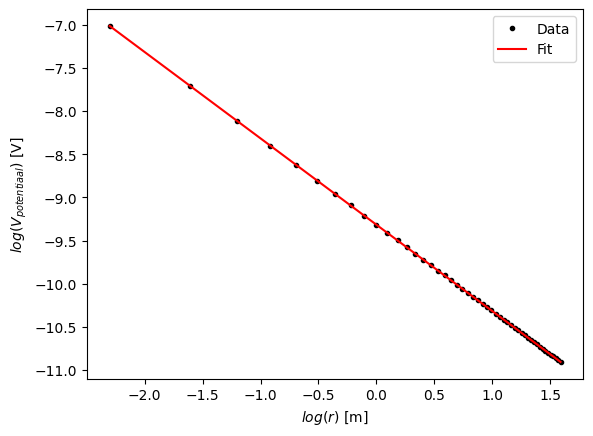

Exponent =  -1.000 ± 0.000


In [3]:
#curve fit library importen
from scipy.optimize import curve_fit

#1
#index waarvoor geldt z = 0
index = find_idx_nearest(z,0)
print(f'De index waarvoor geldt dat z = 0: {index}')

#2
#linear functie defininieren
def lin(x, a, b):
    return a * x + b 

#log van het potentiaal en straal
#moet bij index 1 beginnen, want anders krijgen we een divide by zero error
log_r = np.log(r[1:])
log_V = np.log(V[index, 1:])

var, cov = curve_fit(lin, log_r, log_V)
a_fit, b_fit = var
a_unc, b_unc = np.sqrt(np.diag(cov))

#een x en y fit maken
x_fit = np.linspace(min(log_r), max(log_r), 1000)
y_fit = lin(x_fit, a_fit, b_fit)

#maken van plot
plt.figure()
plt.plot(log_r, log_V, '.k',label = 'Data')
plt.plot(x_fit, y_fit, 'r-', label = 'Fit')
plt.xlabel('$log(r)$ [m]')
plt.ylabel('$log(V_{potentiaal})$ [V]')
plt.legend()
plt.show()

#printen van a
print(f'Exponent =  {a_fit:.3f} ± {a_unc:.3f}')

##### Vraag 1b Het elektrische veld rond een puntlading
1. Voer van vraag 1a 2 tot 4 uit voor het elektrische veld.

De index waarvoor geldt z = 0 voor het elektrische veld: 49


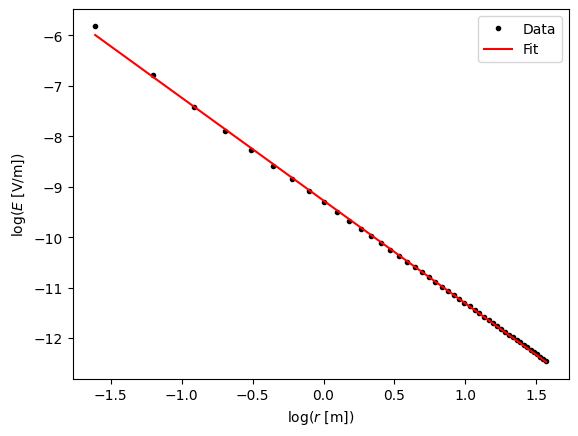

Exponent = -2.040 ± 0.006


In [4]:
#elektrische veld

#2: plot de log van het elektrische veld tegen de straal
#3: fit de log van het elektrische veld met de log van de straal
#4: exponent printen

#hier kunnen we r_for_E en z_for_E gebruiken

#eerst index z = 0 bepalen

index_E = find_idx_nearest(z_for_E, 0)
print(f'De index waarvoor geldt z = 0 voor het elektrische veld: {index_E}')

E_z0 = normE[index_E, 1:]
r_E = r_for_E[1:]

log_r_1b = np.log(r_E)
log_E_1b = np.log(E_z0)

#we hadden al een lineare functie gedefinieerd

var_1b, cov_1b = curve_fit(lin, log_r_1b, log_E_1b)
a_fit_1b, b_fit_1b = var_1b
a_unc_1b, b_unc_1b = np.sqrt(np.diag(cov_1b))

#x en y fit maken zelfde manier als 1a
x_fit_1b = np.linspace(min(log_r_1b), max(log_r_1b), 1000)
y_fit_1b = lin(x_fit_1b, a_fit_1b, b_fit_1b)

#plotten
plt.figure()
plt.plot(log_r_1b, log_E_1b, '.k', label = 'Data')
plt.plot(x_fit_1b, y_fit_1b, 'r-', label = 'Fit')
plt.legend()
plt.xlabel("log($r$ [m])")
plt.ylabel("log($E$ [V/m])")
plt.show()

#bepalen van exponent: we verwachten een exponent van -2, omdat E proprotioneel is met 1/r^2

print(f'Exponent = {a_fit_1b:.3f} ± {a_unc_1b:.3f}')

### 2) Een uniform geladen schijf bestaande uit puntladingen

In de code hieronder wordt een geladen schijf gemaakt via het superpositie principe. Dit wordt gedaan door een rooster van punten in de ruimte te creëren, alle punten die voldoen aan $z = 0$ m en $r < R$ krijgen een lading charge_one_point en vanuit hier wordt het potentiaal bepaald. Hier is de $z$-as de as van de schijf en de r as de afstand tot de $z$-as.



In [5]:
# In vraag 2.1 wordt naar deze cel verwezen.
disk_radius = 10  # (m)
grid_step = 0.1  # (m)
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

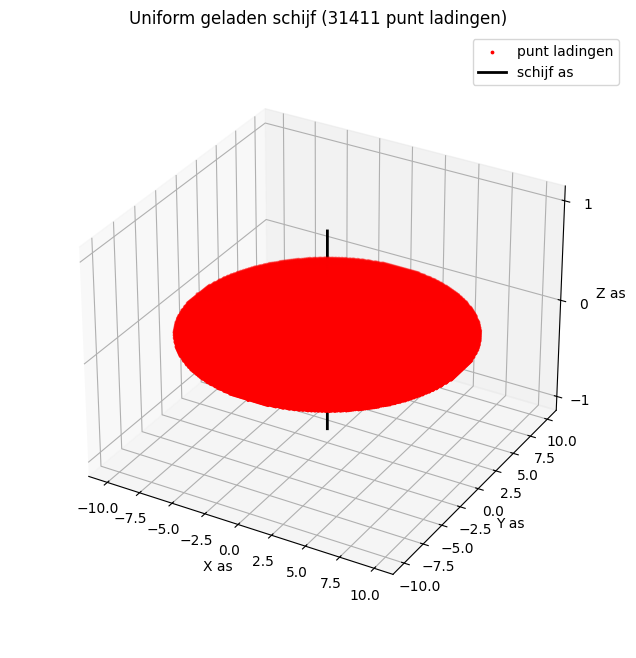

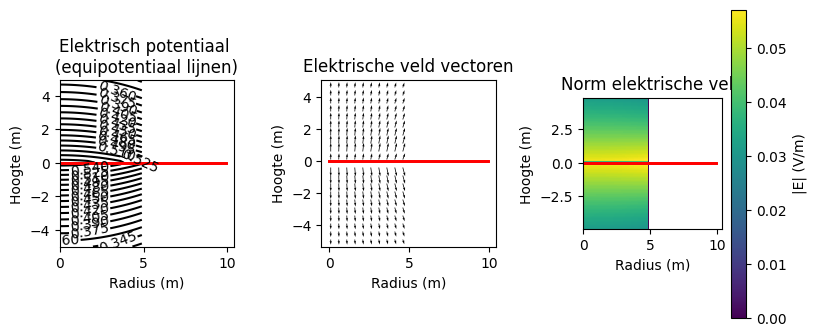

In [6]:
# Kies uit deze cel een van de variabelen en verander die in de cel hierboven pas deze cel zelf niet aan.
r, z, B = initialize_plane_grid_for_uniformly_charged_disk(height_domain, width_domain, grid_step)

idx_z_zero = np.where(abs(z) < 1e-10)[0]
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

V, number_point_charges_on_disk = calculate_V_disk_at_origin_uniform_surface_charge_density(z_coord_DISK, charge_one_point, disk_radius, inter_charge_distance, r, z)
Er, Ez, normE = compute_E_disk(V, B, grid_step)  # gebruik de centered finite-difference method

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_coord_DISK, z_coord_DISK)

#### Vraag 2a

In deze vraag gaan jullie achterhalen wat de variabelen die aan het begin van opgave 2 worden geïnitialiseerd betekenen voor de nauwkeurigheid en snelheid van de code.
Pas voor deze vraag de code die net onder het kopje vraag 2 staat aan. Run dan die cel en de cel daaronder opnieuw om het resultaat van je aanpassing te zien.
1. Wat betekent de disk radius variabele die in de bovenste cel geïnitialiseerd wordt, wat gebeurt er als disk radius naar 0 gaat?
2. Wat betekent gridstep en wat voor impact heeft deze variabele op de simulatie?
3. Pak uit de tweede code cel in opdracht 2 een andere variabelen en onderzoek wat deze variabele doet en wat voor impact die heeft op de simulatie.

##### Antwoorden 2a

1. De disk radius variabele is de straal van het geladen schijf. Naarmate het kleiner wordt (en uiteindelijk naar 0 gaat), zijn er steeds minder puntladingen op de schijf. Als het gelijk is aan 0, wordt de schijf een puntlading (maar dan wordt er wel gedeeld door 0, wat ongedefinieerd is).

2. De grid step is de afstand tussen de roosterpunten. Als dit kleiner wordt, krijg je een hogere nauwkeurigheid maar dat betekent dat er meer geheugen in beslag wordt genomen en dat resulteert in langzamere berekeningen. Als de grid step groter wordt, krijg je een kleinere nauwkeurigheid en snellere berekeningen. Maar, omdat de nauwkeurigheid kleiner wordt, is het ook een stuk minder gedetailleerd.

3. inter_charge_distance: deze variabele bepaald de afstand tussen puntladigen. Als deze kleiner zou zijn, zouden er veel meer puntladingen zijn en dat heeft (net als bij 2) als gevolg dat de berekeningen langzamer gaan. 

#### Vraag 2b Oppervlakte lading

Pas de cel die je in vraag 2a hebt aangepast weer aan naar de originele waardes. Run hierna alle code cellen na vraag 2 weer opnieuw.
Het aantal punten dat gebruikt wordt om de schijf te creëren is number_point_charges_on_disk en de lading van een punt is charge_one_point in Coulomb.
1. Bereken en print de ladingsdichtheid $\sigma$ met een correcte eenheid.

In [7]:
#sigma = Q/A

Q_tot = number_point_charges_on_disk * charge_one_point
A  = np.pi * disk_radius**2
sigma = Q_tot / A

print(f'Oppervlakteladingsdichtheid sigma = {sigma:.3e} C/m^2')


Oppervlakteladingsdichtheid sigma = 9.998e-13 C/m^2


##### Vraag 2c

1. Plot het elektrische potentiaal langs de $r$ as ($z = 0$ m).
2. Plot het potentiaal op de rand van de schijf in hetzelfde figuur $V = \sigma R/(\pi \epsilon_0)$
(bekijk probleem 2.51 in het Griffiths' boek)
3. Plot het potentiaal in het centrum van de schijf in hetzelfde figuur $V = \sigma R/(2 \epsilon_0)$

Text(0, 0.5, '$V [V]$')

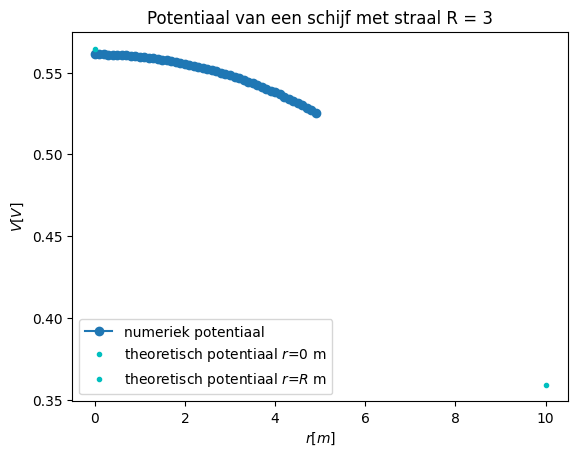

In [8]:
# Vul deze code aan zodat deze vraag 2.3 beantwoord.
idx_z_zero = find_idx_nearest(z,0)

V_0 =  sigma * disk_radius / (2* epsilon0)# potentiaal op r = 0

V_R =  sigma * disk_radius / (np.pi * epsilon0)# potentiaal op de straal van de schijf
r_R =  disk_radius# straal van de schijf

plt.title(f"Potentiaal van een schijf met straal R = 3")
plt.plot(r, V[idx_z_zero], "o-", label="numeriek potentiaal")
plt.plot(0, V_0, "c.", label="theoretisch potentiaal $r$=0 m")
plt.plot(r_R, V_R, "c.", label="theoretisch potentiaal $r$=$R$ m")
plt.legend()
plt.xlabel("$r[m]$")
plt.ylabel("$V [V]$")



#### Vraag 2d

Het theoretische potentiaal op de as van een hele grote schijf ($R>>z$) is:
$V(z, r=0) = \frac{\sigma}{2\epsilon_0} \big( R - |z|\big)$
zie probleem 2.26 in het Griffiths boek.
1. Plot het numeriek berekend elektrische potentiaal op de $z$-as ($r=0$).
2. Plot het theoretische component van het potentiaal op de as van een schijf met ladingsdichtheid $\sigma$.
3. Sla deze plot op.


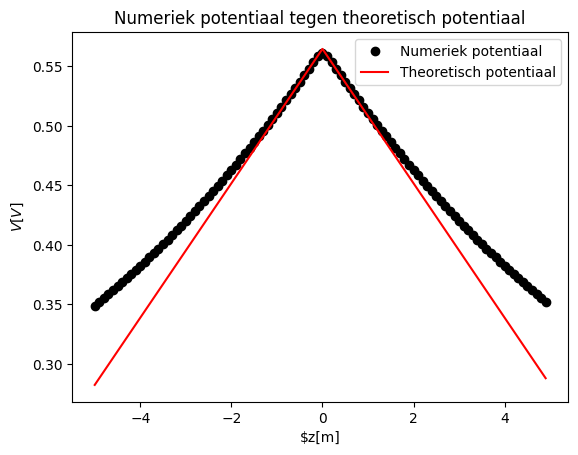

In [9]:
###
###Hier jouw code###
###

#theoretische formule voor het potentiaal 
V_theoretisch = sigma/(2*epsilon0) * (disk_radius - np.abs(z))

#plotten
plt.figure()
plt.title('Numeriek potentiaal tegen theoretisch potentiaal')
plt.plot(z, V[:,0], 'ko', label = 'Numeriek potentiaal')
plt.plot(z, V_theoretisch, 'r-', label = 'Theoretisch potentiaal')
plt.legend()
plt.xlabel('$z[m]')
plt.ylabel('$V [V]$')

plt.savefig("vraag_2d_potentiaal(R = 10)_as.png", dpi=200, bbox_inches="tight")
plt.show()




#### Vraag 2e

Het theoretische elektrische veld van een oneindig geladen oppervlakte is $|E| = \sigma/(2 \epsilon_0)$ (zie Example 2.5 in het Griffith boek).
1. Plot het z-component van het numeriek berekende elektrische veld op de as van de schijf ($r=0$).
2. Plot het theoretische elektrische veld voor een oneindig geladen oppervlak.
3. Sla deze plot ook op.

[]

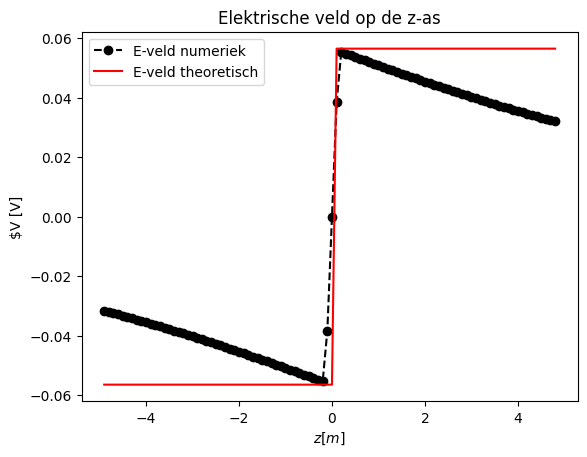

In [10]:
###
###Hier jouw code###
###

#for loop gebruiken

#eerst een lege array maken
E_theoretisch = []
for i in z_for_E:
    if i <= 0:
        E_theoretisch.append(-sigma / (2*epsilon0))
    else:
        E_theoretisch.append(sigma / (2*epsilon0))

#plotten
plt.figure()
plt.title("Elektrische veld op de z-as")
plt.plot(z_for_E, Ez[:,0], 'ko--', label = 'E-veld numeriek')
plt.plot(z_for_E, E_theoretisch, 'r-', label = 'E-veld theoretisch')
plt.xlabel('$z[m]$')
plt.ylabel('$V [V]')
plt.legend()
plt.savefig("vraag_2e_potentiaal(R = 10)_as.png", dpi=200, bbox_inches="tight")

plt.plot()


#### Vraag 2f
1. Waar benadert het elektrische veld van een uniform geladen schijf dat van een oneindig geladen plaat?
2. Beschrijf en verklaar de verschillen die je opvallen in de plot die je bij vraag 2e hebt gemaakt.

##### Antwoorden 2f

*Edit deze markdown cel met je antwoord op vraag 2f.*

Het elektrische veld van een uniform geladen schijf van een oneindig geladen plaat zal ongeveer $E = \frac{\sigma}{2\epsilon_0}$ benaderen

In 2e is er te zien dat er een sprong is in z = 0. Dat kan verklaart worden met dat het veld daar niet goed is gedefinieerd. De rand effecten ontbreken dus voor een oneindige plaat.


#### Vraag 2g

1. Pas helemaal bovenaan in vraag 2 de straal van de schijf aan.
2. Voer dan vragen 2d en 2e opnieuw uit.
3. Voeg de opgeslagen figuren hieronder toe.
4. Beschrijf de verschillen tussen de twee verschillende stralen.

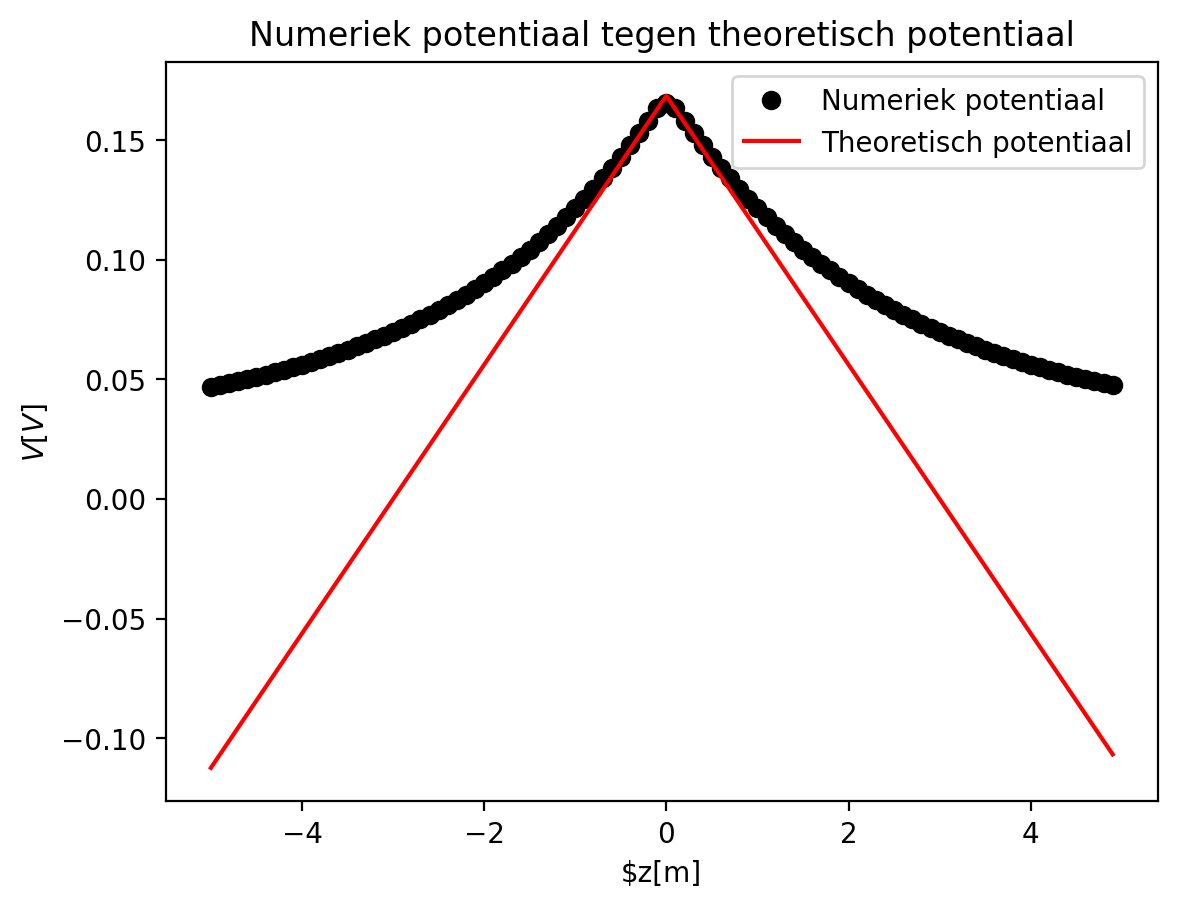

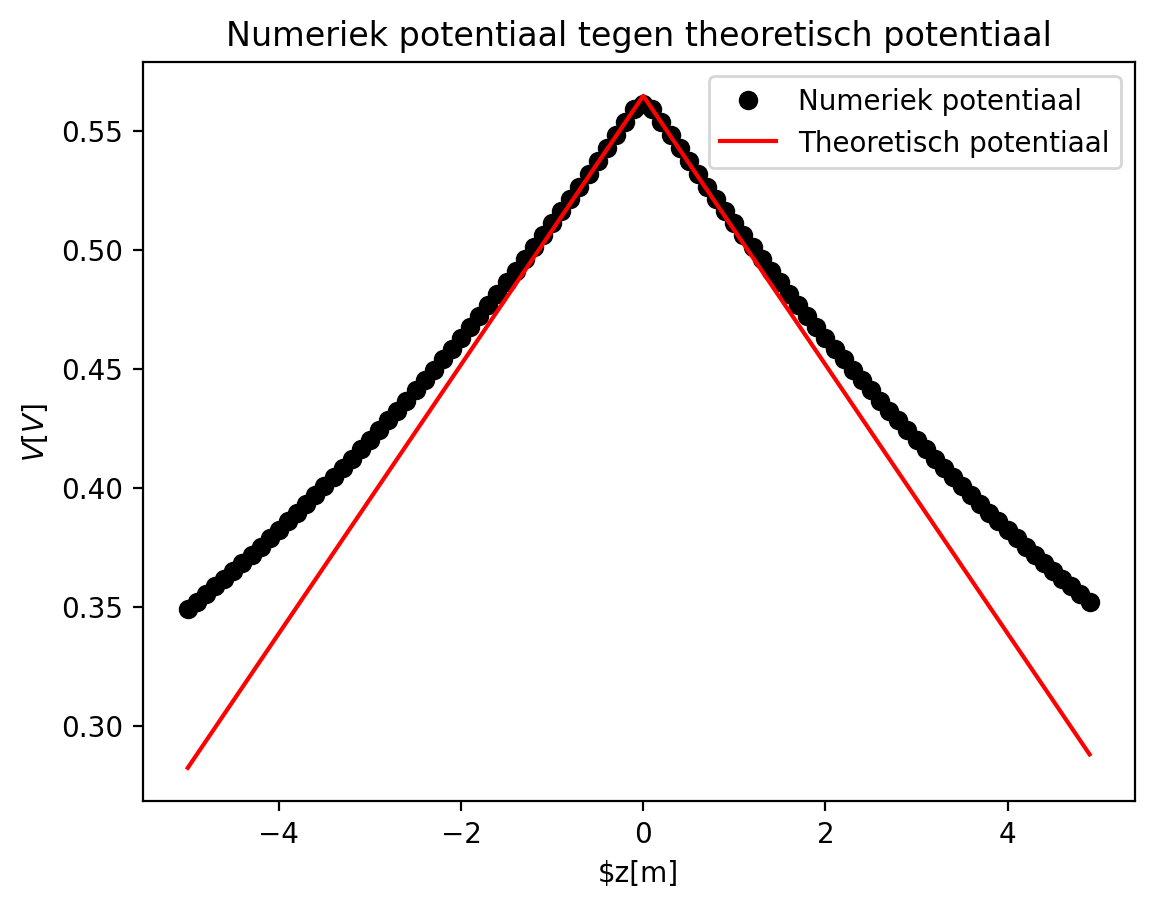

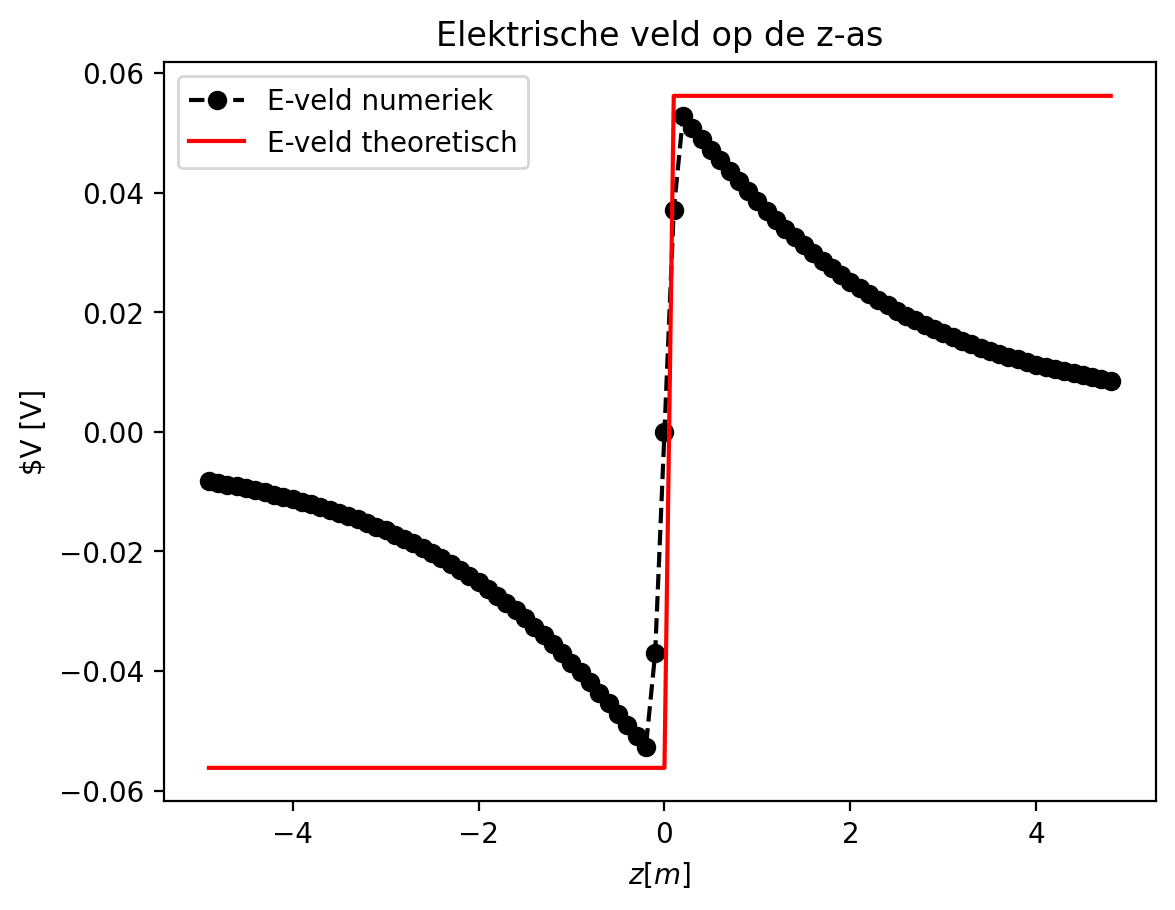

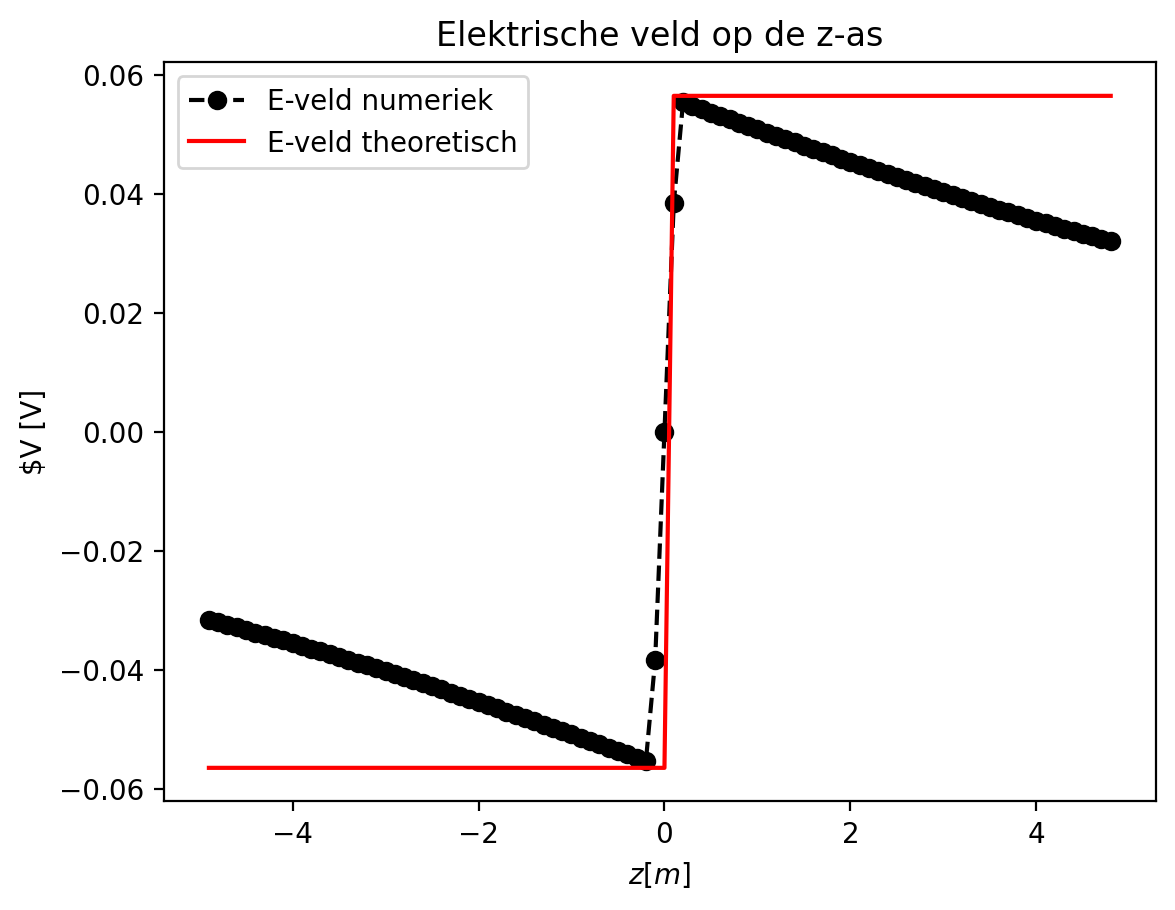

In [11]:

display(Image("vraag_2d_potentiaal_as.png"))
display(Image("vraag_2d_potentiaal(R = 10)_as.png"))

display(Image("vraag_2e_potentiaal_as.png"))
display(Image("vraag_2e_potentiaal(R = 10)_as.png"))



##### Antwoorden 2g

Hoe groter de straal R, hoe beter de schijf bij r = 0 het gedrag van een oneindig plaat beschijft. 

#### Vraag 2h
Het elektrische veld een afstand $z$ boven het midden van een uniform geladen schijf met een straal $R$ en oppervlakte lading $\sigma$ wordt gegeven door:
$$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$$
Zie probleem 2.6 in het boek van Griffith.

1. Wat moet de hoogte $z$ zijn boven de schijf zodat het elektrische veld door de schijf 10% is in vergelijking met dat van een oneindig geladen plaat?

Voeg hieronder je analytische uitwerking toe.

##### Antwoord 2h

Dus we hebben: $$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$$
Voor een oneindige plaat blijft alleen de eerste term over:
$$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} $$

10 procent, dus: $$ \mathbf{E_{fraction}} = 0.1*E $$

Invullen geeft: 

$$ 0.1\frac{\sigma}{2\epsilon_0} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] $$

$$ 0.1 = 1 = \frac{z}{\sqrt{R^2 + z^2}}$$

$$ 0.9 = \frac{z}{\sqrt{R^2 + z^2}} $$

Kwadrateren geeft:

$$ \frac{z^2}{R^2 + z^2} = 0.81 $$

$$ z^2 = 0.81(R^2 + z^2) = 0.81R^2 + 0.81z^2$$

$$ z^2 - 0.81z^2 = 0.81R^2 $$

$$ 0.19z^2 = 0.81R^2 $$

$$ z^2 = \frac{0.81}{0.19}R^2 = \frac{81}{19}R^2 $$

Oftewel

$$ z = \sqrt{\frac{81}{19}}R \approx 2.06R $$

### 3) Een geladen schijf op een constant potentiaal

We zullen nu het verschil bestuderen tussen een uniform geladen schijf en een geleidende schijf die op een bepaald potentiaal gehouden wordt.
De code hieronder lost numeriek de laplace vergelijking op voor een geleidende schijf op een constant potentiaal. Hieruit volgt het potentiaal in de ruimte.

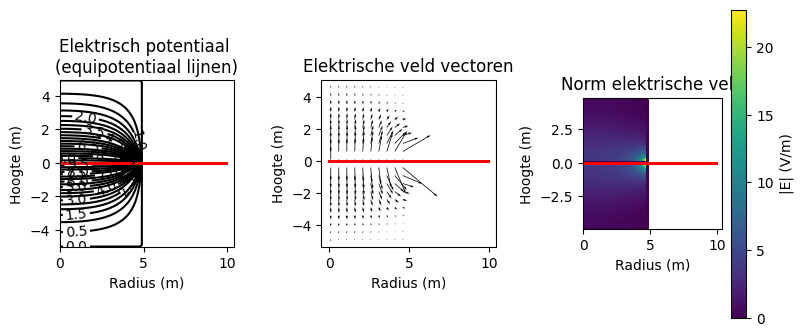

In [12]:
# Run deze cel pas deze niet aan.
V0 = 0  # electric potential at boundary of domain (V)

# Één schijf
z_pos_disk1 = 0  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = z_pos_disk1  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V1)

"""--------------------------------------------------------------------
Veldberekening voor een geleidende schijf
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V1, 1e-3)
Er, Ez, normE = compute_E_disk(V,B,grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)

#### Vraag 3a: De simulatie van het elektrische veld van een geleidende schijf op constant potentiaal

1. Plot de elektrische veld sterkte op de as van de schijf.
2. Print de norm van het elektrische veld op de as heel dicht bij het midden van de schijf, zorg hier voor een nette opmaak.

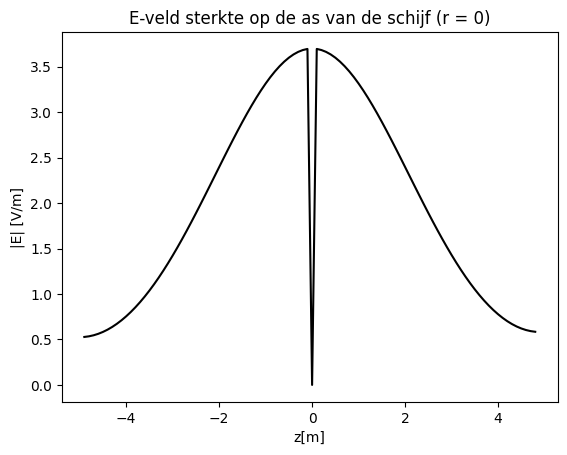

E-veld sterkte (heel) dicht bij het midden:
z = -1.7763568394002505e-14 m
|E| = 6.0411287075012865e-05 V/m
z = 0.09999999999998188 m
|E| = 3.695869846060571 V/m


In [13]:

#1. plot de elektrische veld sterkte op de as van de schijf
#wat geldt op r = 0: Er = 0, alleen Ez contribueert
#aangezien r = 0, zitten we op de z as

#zo dicht mogelijk bij r = 0
index_r0 = find_idx_nearest(r_for_E, 0)

#aangezien Er = 0, gebruiken we alleen maar Ez
Ez_as =  Ez[:, index_r0]
E_as = np.abs(Ez_as) #norm



#plotten
plt.figure()
plt.title('E-veld sterkte op de as van de schijf (r = 0)')
plt.plot(z_for_E, E_as,  'k-')
plt.xlabel('z[m]')
plt.ylabel("|E| [V/m]")
plt.show()



#2. We moeten de norm van het elektrsiche veld op de as heel dicht bij het midden van de schijf gaan printen
i_plus = np.where(z_for_E > 0)[0][0] #eerste punt boven 0
i_min = np.where(z_for_E < 0)[0][-1] #laatste punt onder 0

#printen
print('E-veld sterkte (heel) dicht bij het midden:')
print("z =", z_for_E[i_min], "m")
print("|E| =", E_as[i_min], "V/m")

print("z =", z_for_E[i_plus], "m")
print("|E| =", E_as[i_plus], "V/m")

#### Vraag 3b: De oppervlakte lading in het midden van een geleidende schijf op constant potentiaal

1. Met welke formule kan je de oppervlaktelading benaderen in het midden van de schijf($r=0$, $z=0$)?
2. Print netjes de benadering van de oppervlakte lading in het midden van de schijf.

##### Antwoord 3b

Randvoorwaarden voor binnen en buiten het geleider geven ons:
$$
E_{\perp}^{\text{buiten}} - E_{\perp}^{\text{binnen}} = \frac{\sigma}{\varepsilon_0}
$$

Maar $E_{\perp}^{\text{binnen}} = 0 $ voor een geleider:

$$E_{\perp}^{\text{buiten}} - 0 =  \frac{\sigma}{\varepsilon_0} $$

Ofwel, oplossen voor $\sigma$:


$\sigma = \varepsilon_0 E_{\perp}^{\text{buiten}}$

In het midden van het schijf staat het veld loodrecht op de schijf:

$$
\sigma(0) \approx \varepsilon_0\,\left|E_z(0, 0)\right|
$$

In [14]:
#### Print met deze cel met een nette opmaak je antwoord op vraag 3b 2.

# 3b2: benadering van oppervlaktelading in het midden van de schijf

# Neem veld net boven de schijf op de as (r ~ 0)
E_perp = abs(Ez_as[i_plus])          # V/m, punt net boven z=0 op r=0
sigma0 = epsilon0 * E_perp           # C/m^2

print("Benadering oppervlaktelading in het midden (r = 0):")
print(f"z ≈ {z_for_E[i_plus]:.4e} m (net boven de schijf)")
print(f"|E_perp| ≈ {E_perp:.4e} V/m")
print(f"sigma(0) ≈ ε0 * |E_perp| = {sigma0:.4e} C/m^2")

Benadering oppervlaktelading in het midden (r = 0):
z ≈ 1.0000e-01 m (net boven de schijf)
|E_perp| ≈ 3.6959e+00 V/m
sigma(0) ≈ ε0 * |E_perp| = 3.2723e-11 C/m^2


#### Vraag 3c: De oppervlaktelading van een geleidende schijf op constant potentiaal

De oppervlakte lading $\sigma(r)$ van een geleidende schijf met straal $R$ is niet uniform verdeeld over de schijf, maar wordt gegeven door (Problems 2.58 and 2.63 Griffiths 5th edition):
$$\sigma(r) = \frac{Q}{2 \pi R \sqrt{R^2 - r^2}}$$

1. Bereken de totale lading op de schijf met behulp van vraag 3a en 3b.
2. Vergelijk de oppervlakte lading in het centrum van de geleidende schijf met dat van een uniform geladen schijf met dezelfde totale lading.
3. Plot de oppervlakte lading van de geleidende schijf met de berekende lading $Q$, tussen $r = 0$ en $R$.
4. Plot in hetzelfde figuur de oppervlaktelading van een uniform geladen schijf met dezelfde lading $Q$.


1) Totale lading: Q ≈ 2.056e-08 C
σ_uniform ≈ 6.545e-11 C/m^2
2) Ratio σ_geleider(0)/σ_uniform ≈ 0.500 (verwacht 0.5)


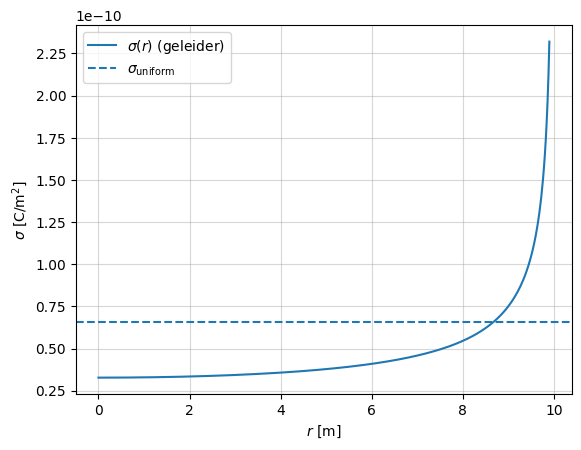

In [ ]:
###
###Jouw code hier###
###

Q = 2*np.pi*disk_radius**2 * sigma0
sigma_uniform = Q/(np.pi*disk_radius**2)

print(f"1) Totale lading: Q ≈ {Q:.3e} C")
print(f"σ_uniform ≈ {sigma_uniform:.3e} C/m^2")
print(f"2) Ratio σ_geleider(0)/σ_uniform ≈ {sigma0/sigma_uniform:.3f} (verwacht 0.5)")

def sigma_cond(r):
    return Q/(2*np.pi*disk_radius*np.sqrt(disk_radius**2 - r**2))

r_plot = np.linspace(0, 0.99*disk_radius, 500)

plt.figure()
plt.plot(r_plot, sigma_cond(r_plot), label="$\sigma(r)$ (geleider)")
plt.axhline(y=sigma_uniform, linestyle="--", label="$\sigma_{\mathrm{uniform}}$")
plt.xlabel("$r$ [m]")
plt.ylabel("$\sigma$ [C/m$^2$]")
plt.grid(alpha=0.5)
plt.legend()
plt.show()

#### Vraag 3d: Het edge effect

1. Bepaal het maximum elektrische veld door de geleidende schijf in de simulatie.
2. Bepaal waar in de ruimte dit maximum zich bevindt.
3. Hoeveel hoger is dit maximum dan het elektrische veld in het midden van de schijf?
4. Print met een nette opmaak de waardes die je hier hebt berekend.
5. Leg uit wat de oorzaak van dit lokaal hoge elektrische veld is?


In [25]:
# Deze cel kan je gebruiken om van vraag 3c 1 tot en met 4 te beantwoorden.


# 3d: edge effect — max veld, locatie, vergelijking met midden

r_mid = 0.5*(r[:-1] + r[1:])

E_absoluut = np.sqrt(Er**2 + Ez**2)
E_max = np.nanmax(E_absoluut)
#definitie van np.nanmax op numpy.org: Return the maximum of an array or maximum along an axis, ignoring any NaNs


flat_idx = np.nanargmax(E_absoluut)                 # index in flattened array (negeert NaNs)
iz_max, ir_max = np.unravel_index(flat_idx, E_absoluut.shape)
#iz_max, ir_max = np.unravel_index()
z_max = z_for_E[iz_max]
r_max = r_mid[ir_max]

i_axis = np.argmin(np.abs(r_mid))                 #dichtst bij r=0 
k_plus = np.where(z_for_E > 0)[0][0]              #eerste punt boven z=0

E_center = E_absoluut[k_plus, i_axis]                   #E net boven het midden
factor = E_max / E_center

print(f"1. Maximum veldsterkte: |E|_max = {E_max:.3} V/m")
print(f"2. Locatie maximum: r ≈ {r_max:.3} m, z ≈ {z_max:.3} m")
print(f"3. De maximale veldsterkte is ongeveer {factor:.1f} keer groter dan de veldsterkte in het midden van de schijf.")


1. Maximum veldsterkte: |E|_max = 22.8 V/m
2. Locatie maximum: r ≈ 4.65 m, z ≈ 0.2 m
3. De maximale veldsterkte is ongeveer 6.2 keer groter dan de veldsterkte in het midden van de schijf.


##### Antwoord 3d.5

*Schrijf hier je argumentatie voor vraag 3d.5.*

Bij een geleider verplaatsen ladingen zich zodanig dat het oppervlak equipotentiaal blijft.

Daardoor wordt de ladingsdichtheid veel hoger bij de rand (zie ook uit 3c):
$[
\sigma(r)\propto \frac{1}{\sqrt{R^2-r^2}}.
]$

Een hogere $\sigma$ betekent een groter lokaal normaal elektrisch veld:
$[
E_\perp \approx \frac{\sigma}{\varepsilon_0}.
]$

Bovendien buigen de veldlijnen bij de rand naar buiten, waardoor het veld lokaal geconcentreerd wordt.

### 4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$

In de cel hieronder wordt weer op dezelfde manier als in opdracht 3 de laplace vergelijking van deze situatie opgelost.

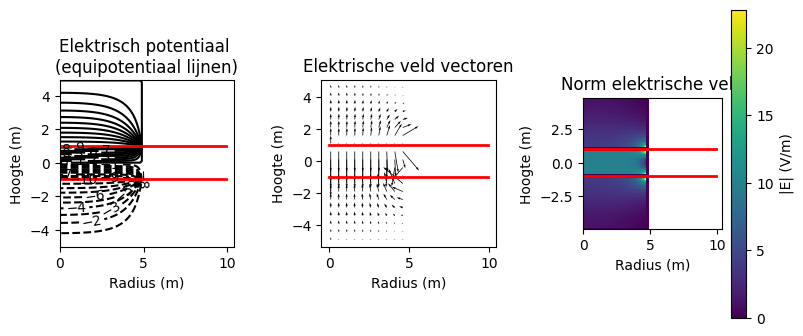

In [ ]:
# Run deze cel en pas de cel aan in vraag 4f.
# Voor twee schijven
spacing_between_disks = 2  # (m)
z_pos_disk1 = spacing_between_disks/2  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = -spacing_between_disks/2  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)
V2 = -10  # elektrische potentiaal van de tweede geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V2)

"""--------------------------------------------------------------------
Veldberekening voor de twee geleidende schijven
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V2, 1e-3)
Er, Ez, normE = compute_E_disk(V, B, grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)


#### Vraag 4a: Het $z$-component van het numeriek berekende elektrische veld van twee geleidende platen

1. Plot het $z$-component van het numeriek berekende elektrische veld op de as van de schijven.


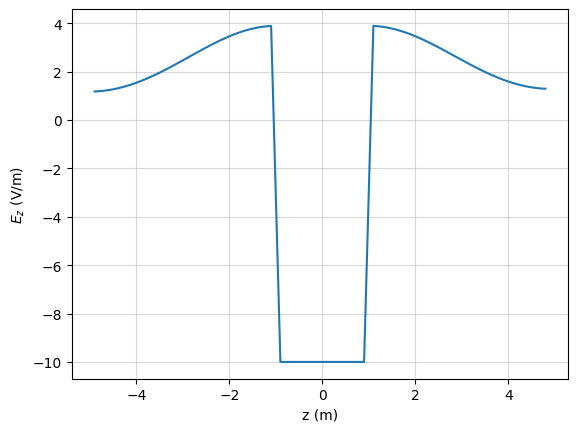

In [ ]:

i_axis = np.argmin(np.abs(r_for_E - 0))   # index dichtst bij r=0
Ez_r0 = Ez[:, i_axis]                     # Ez langs z op r≈0

plt.figure()
plt.plot(z_for_E, Ez_r0)
plt.xlabel("z (m)")
plt.ylabel(r"$E_z$ (V/m)")
plt.grid(alpha=0.5)
plt.show()

#### Vraag 4b: Verschillen tussen verschillende configuraties

1. Gegeven het potentiaal tussen twee geleidende platen, wat is het theoretische elektrische veld in elke regio? Laat dit zien met een afleiding en een schets die de verschillende regio's aangeeft.
2. Beschrijf het numeriek berekende elektrische veld op de as van de schijven, komt dit overeen met het theoretische elektrische veld?
3. Vergelijk het numeriek berekende elektrische veld tussen de twee schijven ($r=0$ and $z=0$) met dat van een enkele geleidende schijf op hetzelfde potentiaal(vraag 3a), welk voordeel heeft deze configuratie?

##### Antwoorden 4b




 Twee grote parallele platen op z = d/2 en z = -d/2 geeft:

$$
V(z)=\frac{2V_1}{d}\,z \qquad \left(-\frac{d}{2}<z<\frac{d}{2}\right)
$$

Dan geldt voor elektrische veld:

$$
\vec{E} = -\nabla V \;\Rightarrow\; E_z = -\frac{dV}{dz} = -\frac{2V_1}{d}
$$

Dus:
Voor z>d/2:  $E \approx 0$
Voor -d/2 < z < d/2:  $E_z \approx -\dfrac{2V_1}{d}$
Voor z<-d/2: $E \approx 0$






E_z is ongeveer constant tussen de twee schijven:
In het midden tussen de platen is  het veld het meest vlak, dus bijna constant.
Dichtbij de randen buigen veldlijnen naar buiten, dus E_z verandert daar.
Buiten het gebied tussen de platen is het elektrische veld niet precies nul, maar wel veel kleiner dan tussen de platen.


Vergelijk het veld in het midden ($r=0$, $z=0$):

 Twee platen: het veld tussen de platen is relatief groot en uniform, ongeveer $|E|\approx 2V_1/d$.
 Enkel schijf op potentiaal:het veld “lekt” in de ruimte en is veel minder uniform; bovendien is het veld buiten de schijf relatief aanwezig.

Voordeel twee platen configuartie: je krijgt een sterker en uniformer elektrisch veld in het meetgebied. Faardoor kun je een condensator/sensor maken met een voorspelbare reactie. 

#### Vraag 4c: De capaciteit tussen twee geleidende platen

1. Bepaal de verwachte oppervlakte lading op de binnenzijde van een van de schijven.
2. Bepaal de verwachte totale lading op beide schijven.
3. Bepaal de capaciteit van deze situatie.
4. Print alle bepaalde waardes op een nette en overzichtelijke manier.

In [ ]:


# 4c: capaciteit tussen twee geleidende platen (V1 en -V1)

# uniforme veld tussen platen, lading zit vooral op de binnenzijden

A = np.pi * disk_radius**2          # oppervlak van 1 schijf 
d = spacing_between_disks           # afstand tussen platen
dV = V1 - V2                        # potentiaalverschil 

E = abs(dV) / d                     
sigma = epsilon0 * E                

Q_plate = sigma * A                 
Q_total = 2 * Q_plate               

C = Q_plate / abs(dV)               # Q/V


print(f"|E| ≈ {E:.4e} V/m")

print(f"σ (binnen) ≈ {sigma:.4e} C/m^2")

print(f"Q (totaal op beide platen) ≈ {Q_total:.4e} C")

print(f"C ≈ {C:.4e} F  = {C*1e12:.2f} pF")

4c: Resultaten twee geleidende platen
A = 3.1416e+02 m^2
d = 2.0000e+00 m
ΔV = 20.00 V
|E| ≈ 1.0000e+01 V/m
σ (binnenzijde) ≈ 8.8540e-11 C/m^2
Q (per plaat, binnenzijde) ≈ 2.7816e-08 C
Q (totaal op beide platen) ≈ 5.5631e-08 C
C ≈ 1.3908e-09 F  = 1390.78 pF


#### Vraag 4d: Theoretische oppervlakte lading

1. Is de oppervlaktelading aan de buitenkant van de schijven gelijk aan nul, beargumenteer waarom wel of niet.
2. Wat is het elektrische veld nabij het oppervlak van een geleider?

##### Antwoorden 4d

*Beantwoord in deze markdown cel vraag 4d.*

De oppervlaktelading aan de buitenkant van de schijf is in het theoretische model wel gelijk aan 0. Er is dan geen veld aan de buitenkant waardoor er ook geen oppervlaktelading $\sigma$ is. In het numerieke model is er wel een veld, waardoor de oppervlaktelading daar niet gelijk is aan 0.

2: Net boven de geleider is er een randvoorwaarde waarvoor geldt dat binnen de geleider het elektrische veld gelijk is aan 0, maar net boven (in de tangentiele richting) is het gelijk aan: $ E = \frac{\sigma}{{\epsilon_0}}$



#### Vraag 4e: Numeriek berekende ladingsdichtheid

1. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net onder de onderste schijf.
2. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de onderkant van de onderste geleidende plaat.
3. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net boven de onderste schijf.
4. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de bovenkant van de onderste geleidende plaat.
5. Print de bepaalde waardes op een nette en overzichtelijke manier.

In [ ]:



# r=0 index
ir0 = np.argmin(np.abs(r_for_E - 0))

# z-positie onderste schijf
z_bot = z_pos_disk2 

# index net onder en net boven de onderste schijf
iz_below = np.where(z_for_E < z_bot)[0][-1]   
iz_above = np.where(z_for_E > z_bot)[0][0]    

Ez_below = Ez[iz_below, ir0]
Ez_above = Ez[iz_above, ir0]


sigma_below = epsilon0 * Ez_below
sigma_above = epsilon0 * Ez_above


print(f"z_onderste schijf = {z_bot:.4e} m")
print(f"Ez net onder = {Ez_below:.4e} V/m")
print(f"sigma onderkant ≈ ε0*Ez = {sigma_below:.4e} C/m^2  (|sigma|={abs(sigma_below):.4e})")

print(f"Ez net boven = {Ez_above:.4e} V/m")
print(f"sigma bovenkant ≈ ε0*Ez = {sigma_above:.4e} C/m^2  (|sigma|={abs(sigma_above):.4e})")

4e: Ladingsdichtheid onderste schijf (r = 0)
z_onderste schijf = -1.0000e+00 m
Ez net onder (z = -1.0000e+00 m) = -3.0538e+00 V/m
sigma onderkant ≈ ε0*Ez = -2.7039e-11 C/m^2  (|sigma|=2.7039e-11)

Ez net boven (z = -9.0000e-01 m) = -1.0000e+01 V/m
sigma bovenkant ≈ ε0*Ez = -8.8540e-11 C/m^2  (|sigma|=8.8540e-11)


#### Vraag 4f: Conclusies over de ladingsdichtheid op de twee schijven

1. Wat kan je uit vraag 4d en e concluderen over de daadwerkelijke lading op een schijf in tegenstelling tot de berekende lading in vraag 4c?
2. Wat is de invloed hiervan op de capaciteit berekend in vraag 4c?
3. Run de cel net onder het kopje vraag 4 opnieuw, maar dan met een kleinere afstand tussen de schijven, wat verandert er?

##### Antwoorden 4f

*Beantwoord vraag 4f in deze cel.*




De totale lading wijkt af van de theoretische model omdat er werd aangenomen dat alle lading op de binnenzijden zat en dat het veld buiten gelijk is aan nul. Echter blijkt dat er ook lading aan de buitenkant zit.

Doordat er lading aan de buitenkant zit, is er een hogere waarde voor Q, waardoor de capaciteit hoger kan zijn (omdat $C = Q/V$).

Als de afstand tussen de schijven kleiner wordt, wordt het elektrische veld tussen de schijven juist groter. Daardoor komt er meerlading aan de binnenkant waardoor het meer zal lijken op het theoretische model. Dit zorgt er ook voor dat de capaciteit zal toenemen.


### 5) Voorbereidende opdracht voor de fysieke DEF ontwerpopdracht

In deze vraag zullen we ingaan op benodigde voorkennis voor de fysieke ontwerpopdracht "Maak een sensor met condensatoren". De formules die je in deze opdracht opstelt, heb je nodig gedurende de fysieke ontwerpopdracht.

In deze vraag zullen we kijken naar de ideale vlakke plaat condensator. Als de afstand tussen de platen veel kleiner is dan de grootte van de platen dan wordt de aanname gemaakt dat het veld tussen de platen constant is. Deze aanname zal niet helemaal overeenkomen met de werkelijkheid, zoals je in deze opdracht en de fysieke DEF ontwerpopdracht achter zal komen.

#### Vraag 5a: Functies voor de capaciteit van enkele opdrachten

1. Vind de formule voor de capaciteit van een vlakke plaat condensator en een cilinder condensator, onder de aanname dat de afstand tussen de platen veel kleiner is dan het oppervlakte van de condensator (vlakke plaat aanname).
2. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een vlakke plaat condensator als output heeft.
3. Vind de formule voor de capaciteit van een cilinder condensator onder de aanname dat de afstand tussen de binnen en buiten wand klein is.
4. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een cilinder condensator als output heeft.

In [ ]:
def vlakkeplaat(A, d, epsilon_r):
    C = epsilon0 * epsilon_r * A / d
    return C

def cilinder(epsilon_r, L, R_buiten, R_binnen):
    C = 2 * np.pi * epsilon0 * epsilon_r * L * R_binnen / (R_buiten - R_binnen)
    return  C

#### Vraag 5b: Capaciteit van enkele simpele condensatoren

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder staan een aantal condensatoren waarvoor jullie de capaciteit gaan berekenen. Print de capaciteit van elke condensator op een nette en overzichtelijke manier.
1. Bereken de capaciteit van een condensator gemaakt van twee vierkante plaatjes van 10 bij 10 cm met een plaatafstand van 1 mm en lucht als medium?
2. Bereken de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm met een lengte van 10 cm en lucht als medium?
3. Bereken de capaciteit van de condensatoren als de afstand tussen de platen verdubbeld
4. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven beschreven als ze gevuld zijn met water.
5. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven als de holte gevuld is met PVC.


In [ ]:
#1: capaciteit condensator gemaakt van twee vierkante plaatjes 10 x 10 cm  met afstand 1 mm en lucht medium

A_1 = (10*0.01) * (10*0.01)
d_1 = 1* 0.001
epsilon_r = 1.0006

C_1 = vlakkeplaat(A_1, d_1, epsilon_r)
print(f"Vlakke plaat: C = {C_1}")

#2. C van cilinder concensator met binnendiameter 9 mm en buitendiameter 10 mm en lengte 10 cm en lucht medium

R_binnen = (9/2)*0.001
R_buiten = (10/2)*0.001
L_cilinder = 10*0.01

C2 = cilinder(epsilon_r, L_cilinder, R_buiten, R_binnen)
print(f"Cilinder: C = {C2}")

#3. Vlakke plaat afstand verdubbled

C3a = vlakkeplaat(A_1, 2*d_1, epsilon_r)

#cilinder
R_buiten_2 = R_binnen + 2*(R_buiten - R_binnen)
C3b = cilinder(epsilon_r, L_cilinder, R_buiten_2, R_binnen)

print(f"Afstand verdubbeld: C ={C3a} voor vlakke plaat, C = {C3b} voor cilinder")

#4 gevuld met water
#vlakke plaat

epsr_water = 80
C4a = vlakkeplaat(A_1, d_1, epsr_water)
C4b = cilinder(epsr_water, L_cilinder, R_buiten, R_binnen)

print(f"Water: C = {C4a} voor vlakke plaat, C = {C4b} voor cilinder")

#5 C als holte is gevuld met PVC

espr_PVC = 4.5
C5a = vlakkeplaat(A_1, d_1, espr_PVC)
C5b = cilinder(espr_PVC, L_cilinder, R_buiten, R_binnen)

print(f"PVC: C = {C5a} voor vlakke plaat, C = {C5b} voor cilinder")

Vlakke plaat: C = 8.8593124e-11
Cilinder: C = 5.0098231353054567e-11
Afstand verdubbeld: C =4.4296562e-11 voor vlakke plaat, C = 2.5049115676527283e-11 voor cilinder
Water: C = 7.0832000000000005e-09 voor vlakke plaat, C = 4.005455235103304e-09 voor cilinder
PVC: C = 3.9843000000000004e-10 voor vlakke plaat, C = 2.2530685697456085e-10 voor cilinder


#### Vraag 5c: Condensatoren uit het dagelijkse leven

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder is een foto te zien van condensatoren die in het dagelijkse leven gebruikt wordt.
Print de capaciteiten in deze vraag op een nette en overzichtelijke manier.
1. In figuur 5.1 is een condensator te zien van 1 $\micro$F, stel deze condensator kan geapproximeerd worden als een cilinder condensator met binnendiameter 5 mm en een buitendiameter van 6 mm. Bereken wat de lengte van de condensator dan zou zijn.
Stel dat we een vierkante plaat condensator hebben van 1 $\micro$F.
2. Bereken hoe lang de vlakke plaat condensator moet zijn als er 0.5 mm tussen de platen zit en de platen 6 mm breed zijn.

![figure 5.1](figures/Condensator_1_uF.jpg)

##### Figure: 5.1 Een 1 microfarad condensator.

In [ ]:
#1 cilinder
C = 1e-6 
R_in = (5e-3)/2
R_out = (6e-3)/2

L_cil = C * (R_out - R_in) / (2*np.pi*epsilon0 * epsilon_r* R_in)
print(f"Lengte cilinder (lucht): {L_cil:.3f} m")

#2 vlakke plaat
d = 0.5e-3
b = 6e-3



L_plaat = C * d / (epsilon0 * epsilon_r * b)
print(f"Lengte vlakke plaat (lucht): {L_plaat}:.3f")

Lengte cilinder (lucht): 3592.941 m
Lengte vlakke plaat (lucht): 9406.298092991206:.3f


#### Vraag 5d: Hoge capaciteit condensatoren

1. Beargumenteer of je antwoorden uit vraag 5c realistisch zijn.
2. Bekijk je formule uit vraag 5a en bedenk hoe ze dit binnen in de condensator opgelost hebben.

##### Antwoorden 5d

*Beantwoord hier de vraag 5d.*

De berekende lengtes zijn niet realistisch (kilometers lang). Dat komt dus helemaal niet in overeenstemming met hoe groot de condensator op de foto is.
Hoe dit kan opgelost zijn is dat de gebruikte medium niet lucht is. Lucht heeft namelijk een permittiviteit van ongeveer 1, wat vrij laag is. Er zal vast een materiaal gebruikt zijn met een veel hogere permittiviteit. 

#### Vraag 5e: Condensator in een achtbaan

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

Met het vak inleidend practicum zijn jullie naar Drievliet gegaan om daar metingen aan de attracties te doen. In Drievliet staat de achtbaan Formule X, deze achtbaan heeft een topsnelheid van 70 $\frac{\text{km}}{\text{h}}$ en bevat een treintje met plek voor 6 mensen. Deze snelheid bereikt de achtbaan door heel snel een karretje weg te schieten, dit wordt gedaan door de treintjes met een lineaire inductie motor te versnellen. Om de impact hiervan op het stroomnet te beperken gebruiken zij een condensator om de energie op te slaan en dan in een keer af te staan aan het treintje. In deze opdracht gaan we kijken wat de afmetingen zouden moeten zijn als ze vlakke plaat condensatoren zouden gebruiken.

De energie die opgeslagen is in een condensator kan berekend worden met de onderstaande formule.

$E = \frac{1}{2} CV^2$
Hierin is $E$ de totaal opgeslagen energie $C$ de capaciteit en $V$ het voltage waarop de condensator opereert, in dit geval $10$ $kV$.
1. Schat de massa van een treintje dat afgeschoten wordt.
2. Bereken de totale energie van het treintje na het afschieten.
3. Bereken de totale capaciteit van de condensator.
4. Bereken het oppervlakte van een vlakke plaat condensator die deze capaciteit heeft als die gevuld is met water en de platen 1 mm van elkaar afstaan.
5. Print alle berekende waardes op een nette en overzichtelijke manier.
6. Is dit realistisch, bedenk een manier hoe dit toch kan in een relatief klein volume.


In [ ]:


# 1: Schatting massa treintje 
m_persoon = 70          
n_personen = 6
m_kar = 800             
m_trein = n_personen*m_persoon + m_kar

print(f"1) Geschatte massa treintje: {m_trein:.0f} kg")

# 2: Totale energie na afschieten
v_kmh = 70
v = v_kmh/3.6           # m/s
E_kin = 0.5 * m_trein * v**2

print(f"2) Kinetische energie bij {v_kmh} km/h: {E_kin:.3e} J")

# 3: Benodigde capaciteit bij 10 kV (10000V)
V = 10e3                
C = 2*E_kin / (V**2)

print(f"3) Benodigde capaciteit bij 10 kV: {C:.3e} F")

# 4: Oppervlakte vlakke plaatcondensator gevuld met water, plaatafstand 1 mm
d = 1e-3                # 1 mm
A = C * d / (epsilon0 * epsr_water)

print(f"4) Benodigde plaatoppervlakte (water, d=1mm): {A:.3e} m^2")

1) Geschatte massa treintje: 1220 kg
2) Kinetische energie bij 70 km/h: 2.306e+05 J
3) Benodigde capaciteit bij 10 kV: 4.613e-03 F
4) Benodigde plaatoppervlakte (water, d=1mm): 6.512e+03 m^2
   (als het een vierkant is: zijde ≈ 80.70 m)


##### Antwoorden 5e

*Edit deze markdown cel met jouw idee hoe de capaciteit toch zo hoog kan zijn.*

De capaciteit is vrij hoog. De rede daarvoor is dat de oppervlakte die is berekend te hoog is. Het kan zijn dat de dikte tussen de platen in werkelijkheid veel kleiner is dan wat hier wordt gebruikt. Daarnaast is er hoogstwaarschijnlijk ook een materiaal gebruikt met een veel hogere permittiviteit.

#### Vraag 5f: Veranderende capaciteit

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

1. Bereken en plot de capaciteit van een vlakke plaat condensator van $10$ bij $10$ $cm$ waarbij de afstand tussen de platen lineair toeneemt van $0.5$ $mm$ tot $5$ $mm$.
2. Bereken en plot de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm en 10 cm lang, waarbij de binnencilinder er langzaam in 10 seconde uitgetrokken wordt.

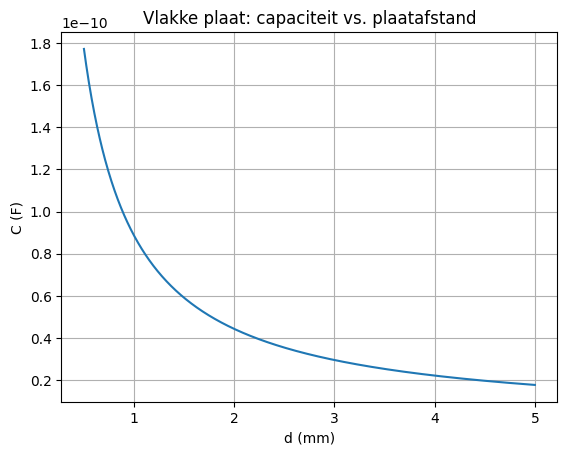

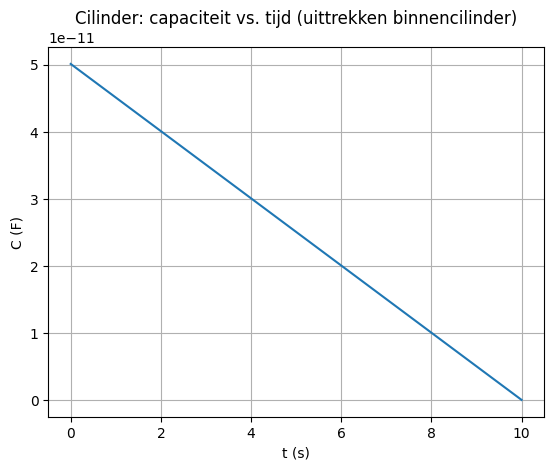

In [ ]:

#10 bij 10

A_plaat = (10e-2) * (10e-2)                 
d_plaat = np.linspace(0.5e-3, 5e-3, 1000)   

C_plaat = vlakkeplaat(A_plaat, d_plaat, epsilon_r)

plt.figure()
plt.plot(d_plaat*1e3, C_plaat)             
plt.title("Vlakke plaat: capaciteit vs. plaatafstand")
plt.xlabel("d (mm)")
plt.ylabel("C (F)")
plt.grid(True)
plt.show()


R_binnen = (9e-3)/2                         
R_buiten = (10e-3)/2                        
L0 = 10e-2                                  

t = np.linspace(0, 10, 1000)                

# lineair uittrekken in 10 seconde
L = L0 * (1 - t/10)
L[L < 0] = 0                                

#gebruiken van eerdere gedefinieerde functie
C_cil = cilinder(epsilon_r, L, R_buiten, R_binnen)

plt.figure()
plt.plot(t, C_cil)
plt.title("Cilinder: capaciteit vs. tijd (uittrekken binnencilinder)")
plt.xlabel("t (s)")
plt.ylabel("C (F)")
plt.grid(True)
plt.show()

## Stop hier met werken tot na de fysieke ontwerpopdracht in week 3.

### 6) Reflectie opdracht voor na de fysieke ontwerpopdracht


Als het goed is, heeft ieder teamlid van deze simulatie-opdracht een andere opstelling ontworpen hebben tijdens de fysieke ontwerpopdracht. Kies in goed overleg voor deze opdracht een van jullie twee ontwerpen.

Voeg hieronder eerst een foto in van je opstelling die je gekozen hebt.

Jullie gaan in deze opdracht het verschil tussen jullie voorspelde verband en jullie uiteindelijke verkregen kalibratie grafiek proberen te verklaren. Er zijn hiervoor drie mogelijke paden die jullie kunnen kiezen om te onderzoeken, Kies deel a, b of c en werk die volledig uit voor jullie ontwerp. Let op je hoeft er maar een uit te werken.

Verander de tekst hieronder zodat deze naar jouw foto verwijst. Zorg dat de foto in de map figures staat!
![figure 5.1](figures/opstelling1.jpg)

#### Vraag 6a: Dunne laag niet meegerekende diëlektricum
Deze vraag is goed om te kiezen als je in je ontwerp een kleine laag extra materiaal hebt en deze tijdens de ontwerpopdracht niet hebben meegenomen in je theoretisch kalibratie grafiek.

1. Maak een nieuwe schets van je opstelling waarbij je de dikte van het extra diëlektricum meeneemt.
2. Leid de analytische oplossing af van de capaciteit van de hierboven getekende situatie.
3. Programmeer de analytische oplossing in python.
4. Maak hierna een plot van het kalibratiegrafiek, oude en nieuwe analytische oplossing in een grafiek.
5. Beschrijf en verklaar de verschillen tussen de grafieken.


##### Antwoorden 6a

*Laat in deze cel je analytische oplossing met schets zien, dit mag met foto's of via LATEX.*

In [ ]:
# Schrijf hier de code voor je oplossing. Gebruik hier je eerder gemaakte functies
# def condensator_extra_laag(#jouw variabelen): # Schrijf hier jouw functie
    ## je functie


### Maak hier je plot

##### Antwoorden 6a

*Beschrijf en verklaar je verschillen in deze markdown cel.*

#### Vraag 6b1: Lading op een condensator met het edge effect meegenomen

In deze opdracht gaan we verder in op het Edge effect en de invloed daarvan op de praktische capaciteit. Deze opdracht bouwt voort op de vraag 4.3.
Jullie hebben tijdens de ontwerpopdracht vierkante platen gebruikt in tegenstelling tot de ronde platen waarvoor de factoren in figure[label] zijn afgeleid. Er is onderzoek gedaan naar de factoren waarmee de praktische capaciteit vergeleken met de daadwerkelijke capaciteit verschilt dat onderzoek vind je hier: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=311759. Zoek in het onderzoek tabel 1 en formules 22 en 36 op.

1. Vergelijk de factor waarmee de schijf(disk) condensator verschilt met die van de vierkante plaat, kunnen we de vierkante plaat factor benaderen met de factor voor een disk condensator? Vergelijk het procentuele verschil tussen de factoren van de circulaire en vierkante platen, met de onzekerheden die in de meting zitten.



##### Antwoord 6b1

In het onderzoek wordt formule (22) gebruikt om de factor te berekenen: $b=\frac{d}{w}$.  
In dit geval is $A=0.01$, dus $w=\sqrt{A}=0.10~\text{m}$ en $d=1.5~\text{mm}=0.0015~\text{m}$.  
Dus dan is $b=\frac{0.0015}{0.10}=0.015$, wat kleiner is dan het bereik waarvoor de square-fit in het paper expliciet is gegeven.


Procentuele verschil:
$$
\%\Delta=\frac{C_{DN}-C_{SN}}{C_{SN}}\times 100\%.
$$

Uit Table~I volgt:
$$
\begin{aligned}
b=0.2:&\quad C_{DN}=1.58007,\; C_{SN}=1.54987 \Rightarrow \%\Delta \approx 1.95\%,\\
b=0.3:&\quad \%\Delta \approx 2.57\%,\\
b=0.5:&\quad \%\Delta \approx 3.70\%,\\
b=0.7:&\quad \%\Delta \approx 4.63\%.
\end{aligned}
$$
Het verschil tussen disk en square blijft dus maar enkele procenten (orde $2\%-5\%$).

Onze opstelling met veertjes geeft een grotere onzekerheid in de effectieve plaatafstand $d$.  
Voor $C\propto 1/d$ geldt:
$$
\frac{\Delta C}{C}\approx \frac{\Delta d}{d}.
$$
Zelfs een conservatieve afstandsonzekerheid van $\Delta d=0.1~\text{mm}$ bij $d=1.5~\text{mm}$ geeft al:
$$
\frac{\Delta C}{C}\approx \frac{0.1}{1.5}\approx 6.7\%.
$$
Dit is groter dan het verschil van $2\%-5\%$ tussen disk en square factoren. Daarom kunnen we de vierkante plaatfactor in onze analyse benaderen met de disk-factor.



*Vergelijk hier de factoren tussen de circulaire en vierkante vlakke plaat condensatoren.*

#### Vraag 6b2: Capaciteit van een condensator met het edge effect meegenomen

Vanaf hier nemen we aan dat factor van de circulaire platen ongeveer gelijk is aan de factor voor vierkante platen. De factor die de capaciteit van de vlakke plaat approximatie linkt aan de werkelijke capaciteit noemen we vanaf nu de idealiteitsfactor.

1. Bereken de daadwerkelijke theoretische capaciteit van de condensator uit de sanity check 3 van de fysieke ontwerpopdracht en print deze op een nette manier.
2. Vergelijk dit met de daadwerkelijke theoretische capaciteit met de capaciteit die je op de dag zelf hebt gemeten.

Vanaf hier gaan we verder met jullie sensor van de ontwerpopdracht "Maak een sensor met condensatoren":

3. Reken je theoretische kalibratie grafiek om met de idealiteitsfactor.
4. Vergelijk je nieuwe theoretische kalibratiegrafiek van je praktische kalibratiegrafiek van de dag zelf.

Gefitte parameters:
d0 = 3.187 mm
alpha = 0.398 mm/kg


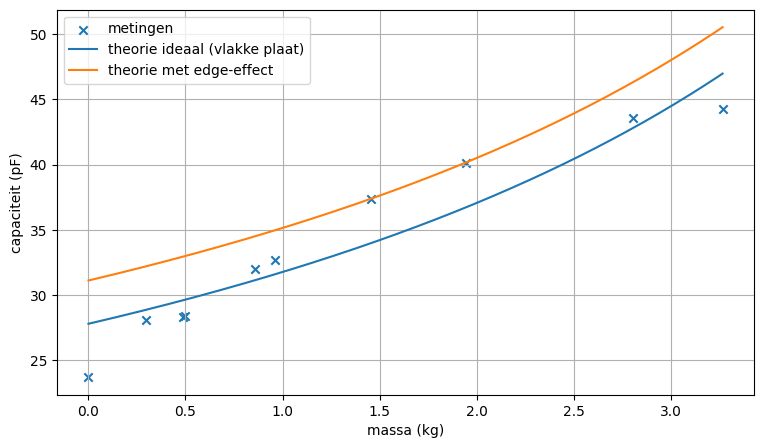

In [ ]:

massa = np.array([0, 0.2952, 0.4884, 0.8588, 0.961, 0.4962, 1.457, 1.946, 2.804, 3.268])  # kg
capaciteit = np.array([23.7, 28.1, 28.3, 32.0, 32.7, 28.4, 37.4, 40.1, 43.6, 44.3]) * 1e-12  # F

A = 0.01  # opp plaat

# Nishiyama & Nakamura (disk): C_DN = 1 + 2.367 * b^0.867
def k_edge_disk(b):
    
    return 1 + 2.367 * (b ** 0.867)

def C_niet_ideaal(A, d, epsilon_r):
   
    w = np.sqrt(A)      
    b = d / w
    k = k_edge_disk(b)
    return k * vlakkeplaat(A, d, epsilon_r), k, b
#model voor afstand als functie van massa
def d_van_m(m, d0, alpha):
    # d0 in meter, alpha in meter/kg
    return d0 - alpha * m

#ideale C
def C_ideal_van_m(m, d0, alpha):
    d = d_van_m(m, d0, alpha)
    return vlakkeplaat(A, d, epsilon_r)

#edge van C
def C_edge_van_m(m, d0, alpha):
    d = d_van_m(m, d0, alpha)
    C_edge, _, _ = C_niet_ideaal(A, d, epsilon_r)
    return C_edge


p0 = [0.0020, 0.0002]  # startwaarden: d0=2 , alpha=0.2

#curve fit
params, cov = curve_fit(C_ideal_van_m, massa, capaciteit, p0=p0, maxfev=10000)
d0_fit, alpha_fit = params

#printen fit
print(f"Gefitte parameters:")
print(f"d0 = {d0_fit*1e3:.3f} mm")
print(f"alpha = {alpha_fit*1e3:.3f} mm/kg")


m_grid = np.linspace(massa.min(), massa.max(), 200)
C_id_fit = C_ideal_van_m(m_grid, d0_fit, alpha_fit)
C_ed_fit = C_edge_van_m(m_grid, d0_fit, alpha_fit)


plt.figure()
plt.scatter(massa, capaciteit*1e12, label="metingen", marker="x") #alles keer e12, omdat ze dan beter geplot kunnen worden. e12 is van de orde pico.
plt.plot(m_grid, C_id_fit*1e12, label="theorie ideaal (vlakke plaat)")
plt.plot(m_grid, C_ed_fit*1e12, label="theorie met edge-effect")
plt.xlabel("massa (kg)")
plt.ylabel("capaciteit (pF)")
plt.grid(True)
plt.legend()
plt.show()

##### Antwoorden 6b2

*Doe in deze markdown cel je vergelijkingen voor de sanity check condensator en je kalibratiegrafiek.*

Aspect ratio uit het verslag werd gegeven als:
$$
b=\frac{d}{w}, \qquad \text{met } A=w^2 \Rightarrow w=\sqrt{A}.
$$
Voor onze platen is $A=0.01~\text{m}^2$, dus $w=\sqrt{0.01}=0.10~\text{m}$ en bij de sanity check afstand $d=1.5~\text{mm}=0.0015~\text{m}$. Dan volgt:
$$
b=\frac{0.0015}{0.10}=0.015.
$$

Omdat onze $b$ klein is en we in 6b1 hebben laten zien dat disk en square factoren slechts enkele procenten verschillen, gebruiken we de disk-fit als benadering voor de idealiteitsfactor:
$$
k(b)=1+2.367\,b^{0.867}.
$$
De nieuwe theoretische capaciteit wordt dan:
$$
C_{\text{edge}}(d)=k(b)\,C_{\text{ideal}}(d),
$$
waarbij $C_{\text{ideal}}(d)$ uit onze bestaande functie $\texttt{vlakkeplaat}(A,d,\epsilon_r)$ komt.

 
Met $A=0.01~\text{m}^2$ en $d=1.5~\text{mm}$ krijgen we uit het ideale vlakke-plaat model een capaciteit van $C_{\text{ideal}}$.  
Met het edge-effect wordt dit $C_{\text{edge}}=k(b)\,C_{\text{ideal}}$, wat maar een kleine toename geeft. Dit komt omdat $k(b)$ maar iets groter is dan 1.
Onze gemeten waarde in de tabel is $C_{\text{meet}}=51.3~\text{pF}$. Dus het edge effect heeft een vrij kleine correctie. 
 
Daarna is de theoretische kalibratiegrafiek opnieuw berekend door voor elke afstand $C_{\text{edge}}$ te bepalen. De nieuwe curve ligt een klein beetje boven de oude curve. In vergelijking met de meetpunten verklaart het edge effect een deel van de afwijking, maar het grootste verschil wordt bepaald door andere effecten: slechte alignment platen en onzekerheid in de afstand $d$.


#### Vraag 6c: Niet linear diëlektricum optie 1

Niet alle materialen zijn een lineair diëlektricum. Een aantal van de materialen die sterk niet lineair gedrag vertonen zijn: sponzen, foam & rubber. Als je in je opdracht een materiaal gebruikt heb waarvan je verwacht dat het verband sterk niet lineair is kan dit een hele goede opdracht zijn.
| Materiaal |$\chi_2$   |
| :-------------|:-------------|
| Spons|  |

Als jouw materiaal hier niet tussen staat dan kan je zelf op zoek naar een waarde van $\chi_2$ in de literatuur.

#### Vraag 6c1

1. Leidt het D veld van de condensator af uit de wet van Gauss.
2. Vindt een analytische uitdrukking voor het elektrisch veld in termen van het D veld.

##### Antwoorden 6c 1

*Antwoord vraag 6c 1.*

#### Vraag 6c2

1. Programmeer je oplossingen voor het D en E veld in python, gebruik het D veld uit je fysieke ontwerpopdracht.

Als je het elektrische veld van een vierkante vlakke plaat condensator weet kan je de capaciteit berekenen met de onderstaande formule:
$C = \frac{A
E_z \epsilon_0}{\Delta V}$

2. Plot de capaciteit van het niet lineaire diëlektricum, het theoretische kalibratiegrafiek en de uiteindelijke kalibratiegrafiek van de fysieke ontwerpopdracht.
3. Verklaar verschillen tussen de grafieken.

In [ ]:
 # Pas deze code aan zodat jouw opstelling doorgerekend wordt
def E_condensator(x1, x2, D):
    return None

#### Vraag 7

Hoeveel van de afwijking tussen je metingen en je oorspronkelijke voorspelde kalibratiegrafiek wordt verklaard door wat je bij vraag 6 hebt uitgerekend? Kan je een (aantal) elektrisch veld en capaciteit gerelateerde reden(en) verzinnen wat de rest van de afwijking tussen meting en voorspelde kalibratiegrafiek kan verklaren.

##### Antwoorden 7

*Antwoord vraag 7, de laatste.*

In vraag 6 wordt er verklaart dat het deel van de afwijking komt door edge effects. De rest van de afwijkingen komt door onnauwkeurigheden (bijvoorbeeld de alignment van platen), onzekerheid in afstand $d$ en het feit dat de omgeving niet ideaal zijn.